# Laboratorio 5. Clasificación de tweets usando minería de texto y análisis de sentimiento.
**Asignatura:** CC3084 – Data Science  
**Facultad de Ingeniería – Departamento de Ciencias de la Computación**  
**Universidad del Valle de Guatemala – Semestre II 2026**  

---
Este notebook presenta la solución completa y reproducible del **Laboratorio 5**, estructurada de acuerdo con los ejercicios e instrucciones oficiales.


## Preparación e Importación de Módulos

In [3]:
import sys
from pathlib import Path

# Agregar directorio src al path
PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lab5.data import load_dataset, add_preprocessed_columns, clean_tweet
from lab5.eda import dataset_summary, export_eda, generate_wordclouds, generate_top_words_histograms, CLASS_NAMES, COLORS
from lab5.ngrams import ngram_frequencies, frequencies_by_class, export_ngrams
from lab5.sentiment import add_sentiment_features, compute_tweet_sentiment, top_sentiment_tweets, sentiment_by_class_summary
from lab5.modeling import compare_all_models, get_classifiers
from lab5.predictor import predict_tweet

pd.set_option('display.max_colwidth', None)
print("Entorno cargado exitosamente.")

ModuleNotFoundError: No module named 'seaborn'

---
## 1. Carga y Descripción del Dataset (Ejercicios 1 y 2)

Se descarga y valida el dataset `train.csv` de la competencia **Natural Language Processing with Disaster Tweets** de Kaggle.

In [2]:
# Cargar dataset original
data_raw = load_dataset(PROJECT_ROOT / "data" / "raw" / "train.csv")
data = add_preprocessed_columns(data_raw)

# Resumen básico
print(f"Filas totales: {len(data):,}")
print(f"Columnas: {list(data_raw.columns)}")
display(dataset_summary(data))

Filas totales: 7,613
Columnas: ['id', 'keyword', 'location', 'text', 'target']


,metrica,valor
0,filas,7613.00
1,columnas_originales,5.00
2,ids_unicos,7613.00
3,keywords_unicos,221.00
4,locations_unicas,3341.00
5,duplicados_fila_completa,0.00
6,textos_duplicados,110.00
7,caracteres_promedio,101.04
8,palabras_promedio_original,14.90
9,palabras_promedio_limpio,8.56


---
## 2. Limpieza y Preprocesamiento de Datos (Ejercicio 3)

### 2.1. Decisiones de Limpieza Implementadas:
1. **Decodificación HTML y Minúsculas**: Conversión de entidades como `&amp;` a `&` y minúsculas generalizadas.
2. **Eliminación de URL y Menciones**: Remoción de enlaces (`http...`) y menciones (`@usuario`) para prevenir sobreajuste.
3. **Preservación de Hashtags**: Remoción del símbolo `#` conservando el término (ej. `#WildFire` -> `wildfire`).
4. **Tratamiento de Puntuación y Apóstrofes**: Eliminación de signos de puntuación y apóstrofes.
5. **Filtrado de Stopwords**: Eliminación de palabras vacías del inglés mediante NLTK/scikit-learn.
6. **Conservación de Números Críticos**: Retención de secuencias numéricas clave como `911` por su alto valor en emergencias.

### 2.2. Discusión sobre Emoticones y Puntuación:
Para el **Análisis de Sentimiento (VADER)** se preservan emoticones, signos de exclamación y mayúsculas en el texto original, ya que ajustan la intensidad emocional. Para la **vectorización TF-IDF de temas**, se utiliza el texto limpio para reducir la dimensionalidad del vocabulario.

In [3]:
# Muestra de texto original vs texto limpio
sample_df = data[['text', 'text_clean']].head(5)
display(sample_df)

,text,text_clean
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake allah forgive
1,Forest fire near La Ronge Sask. Canada,forest near la ronge sask canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,residents asked shelter place notified officers evacuation shelter place orders expected
3,"13,000 people receive #wildfires evacuation orders in California",13 000 people receive wildfires evacuation orders california
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,just got sent photo ruby alaska smoke wildfires pours school


---
## 3. Frecuencias de N-gramas y Probabilidades Empíricas (Ejercicio 4)

Calculamos las frecuencias absolutas y probabilidades empíricas de unigramas y bigramas por cada clase.

In [4]:
# Generar n-gramas por clase
freq_df = frequencies_by_class(data, top_k=10)

print("--- Top 10 Unigramas ---")
display(freq_df[freq_df['n'] == 1][['categoria', 'ngrama', 'frecuencia', 'probabilidad']])

print("\n--- Top 10 Bigramas ---")
display(freq_df[freq_df['n'] == 2][['categoria', 'ngrama', 'frecuencia', 'probabilidad']])

--- Top 10 Unigramas ---


,categoria,ngrama,frecuencia,probabilidad
0,No desastre,like,254,0.007293
1,No desastre,im,246,0.007064
2,No desastre,just,231,0.006633
3,No desastre,new,168,0.004824
4,No desastre,dont,142,0.004077
5,No desastre,body,114,0.003273
6,No desastre,2,112,0.003216
7,No desastre,video,96,0.002757
8,No desastre,people,92,0.002642
9,No desastre,love,90,0.002584



--- Top 10 Bigramas ---


,categoria,ngrama,frecuencia,probabilidad
10,No desastre,cross body,39,0.001279
11,No desastre,liked video,34,0.001115
12,No desastre,body bag,26,0.000853
13,No desastre,body bagging,24,0.000787
14,No desastre,burning buildings,23,0.000754
15,No desastre,body bags,21,0.000689
16,No desastre,looks like,21,0.000689
17,No desastre,reddit quarantine,21,0.000689
18,No desastre,content policy,20,0.000656
19,No desastre,feel like,20,0.000656


### Discusión sobre N-gramas:
- **Unigramas**: Términos como `fire`, `news`, `disaster`, `california`, `suicide` identifican fuertemente la categoría de desastre.
- **Bigramas**: Aportan contexto local esencial. Expresiones como `suicide bomber`, `forest fire`, `oil spill` o `buildings collapsed` resuelven la ambigüedad que tendría una palabra aislada.

---
## 4. Análisis Exploratorio de Datos (EDA) y Visualización (Ejercicio 5)

Visualizamos la distribución de clases, nubes de palabras (**WordCloud**) e histogramas de frecuencia.

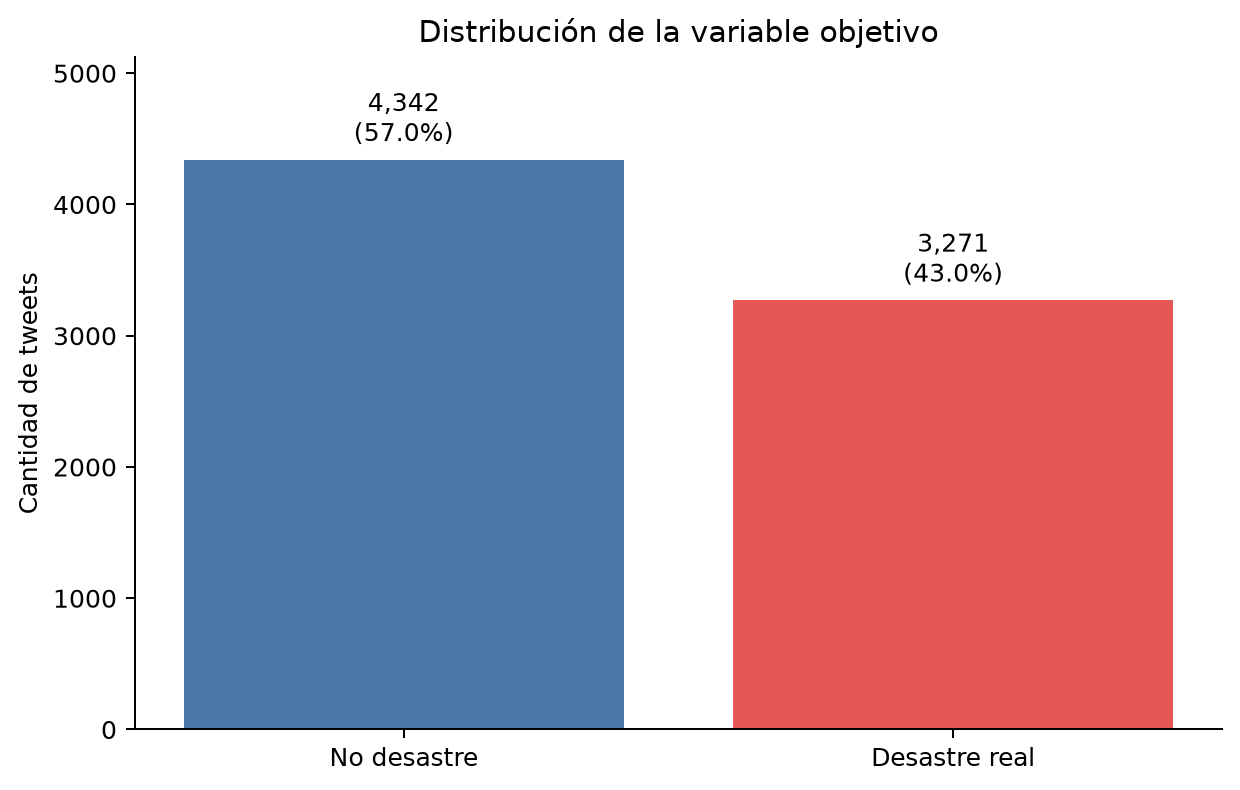

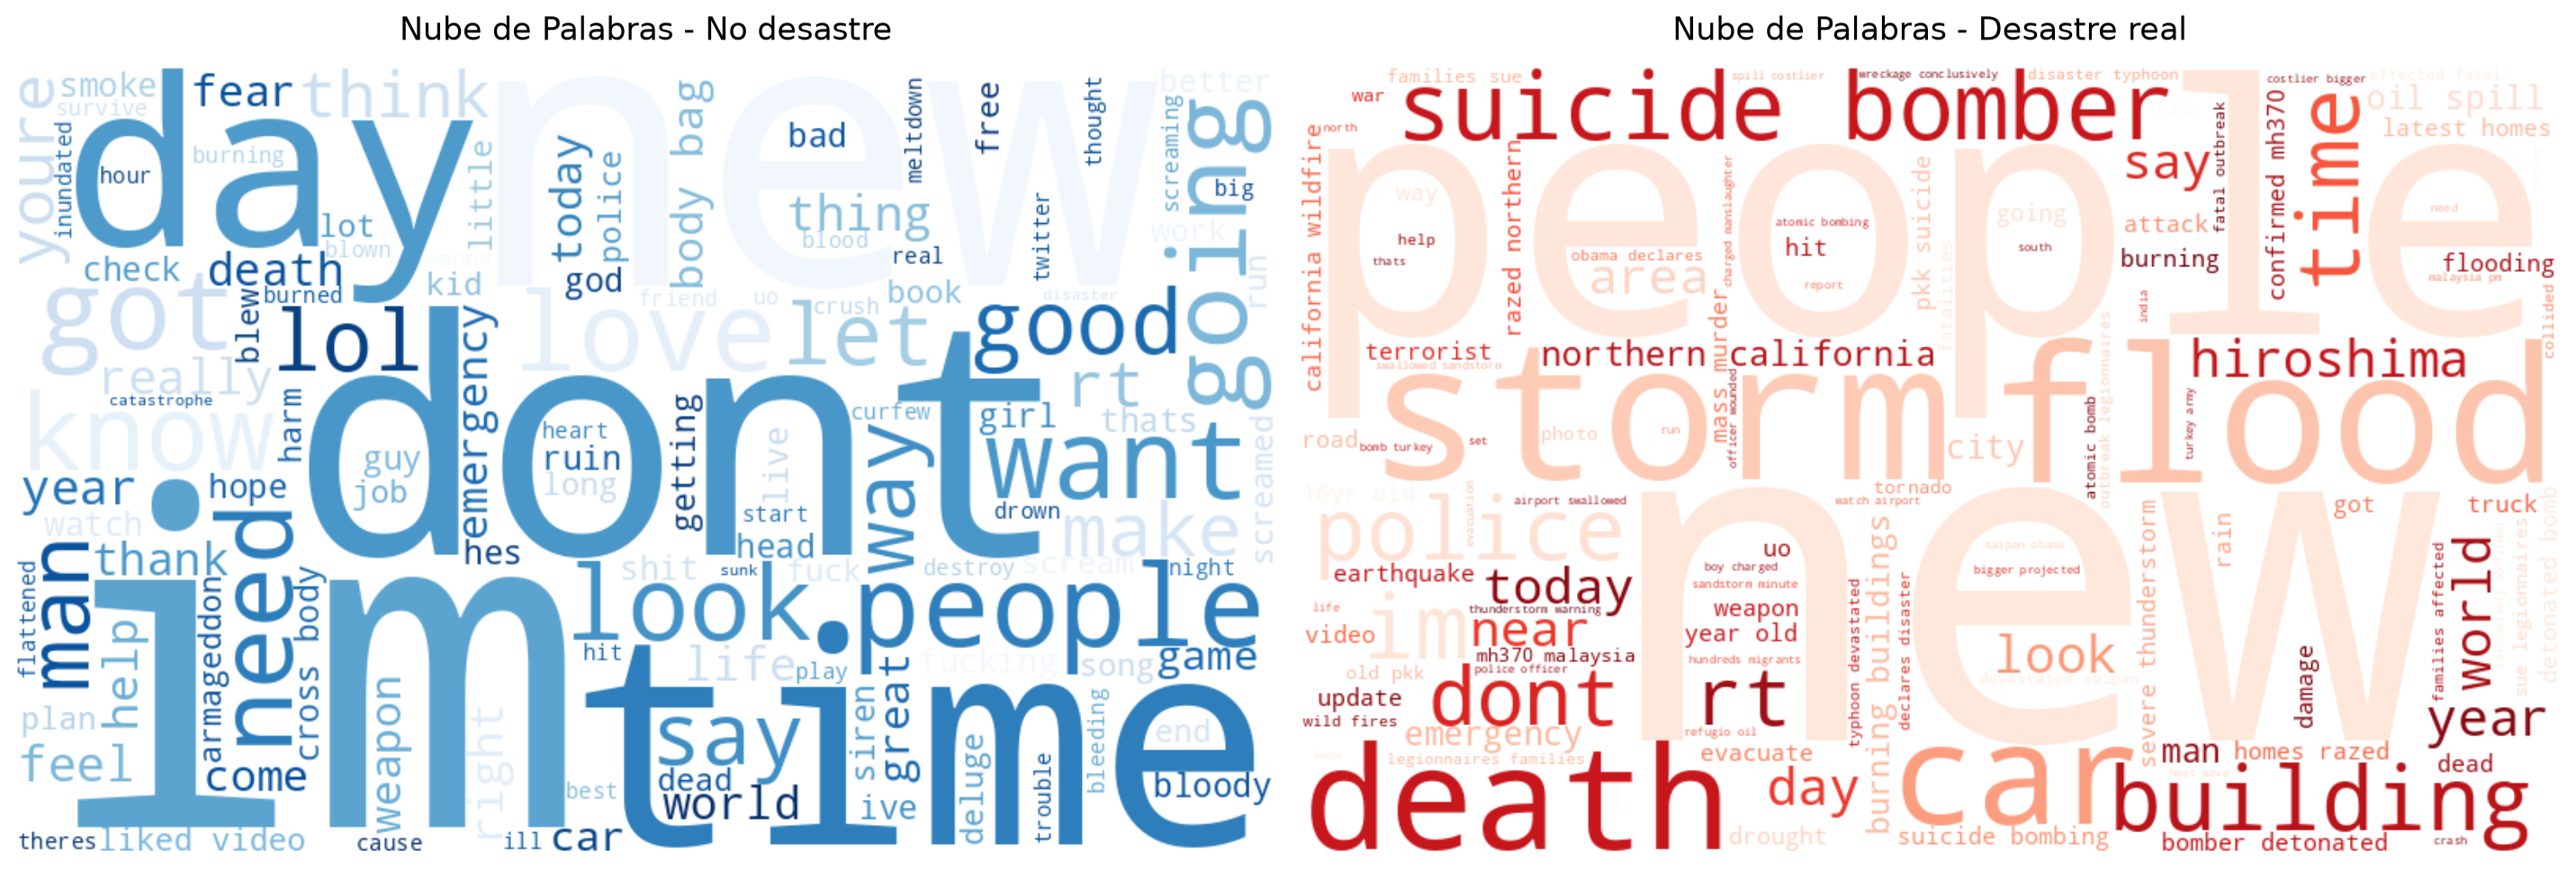

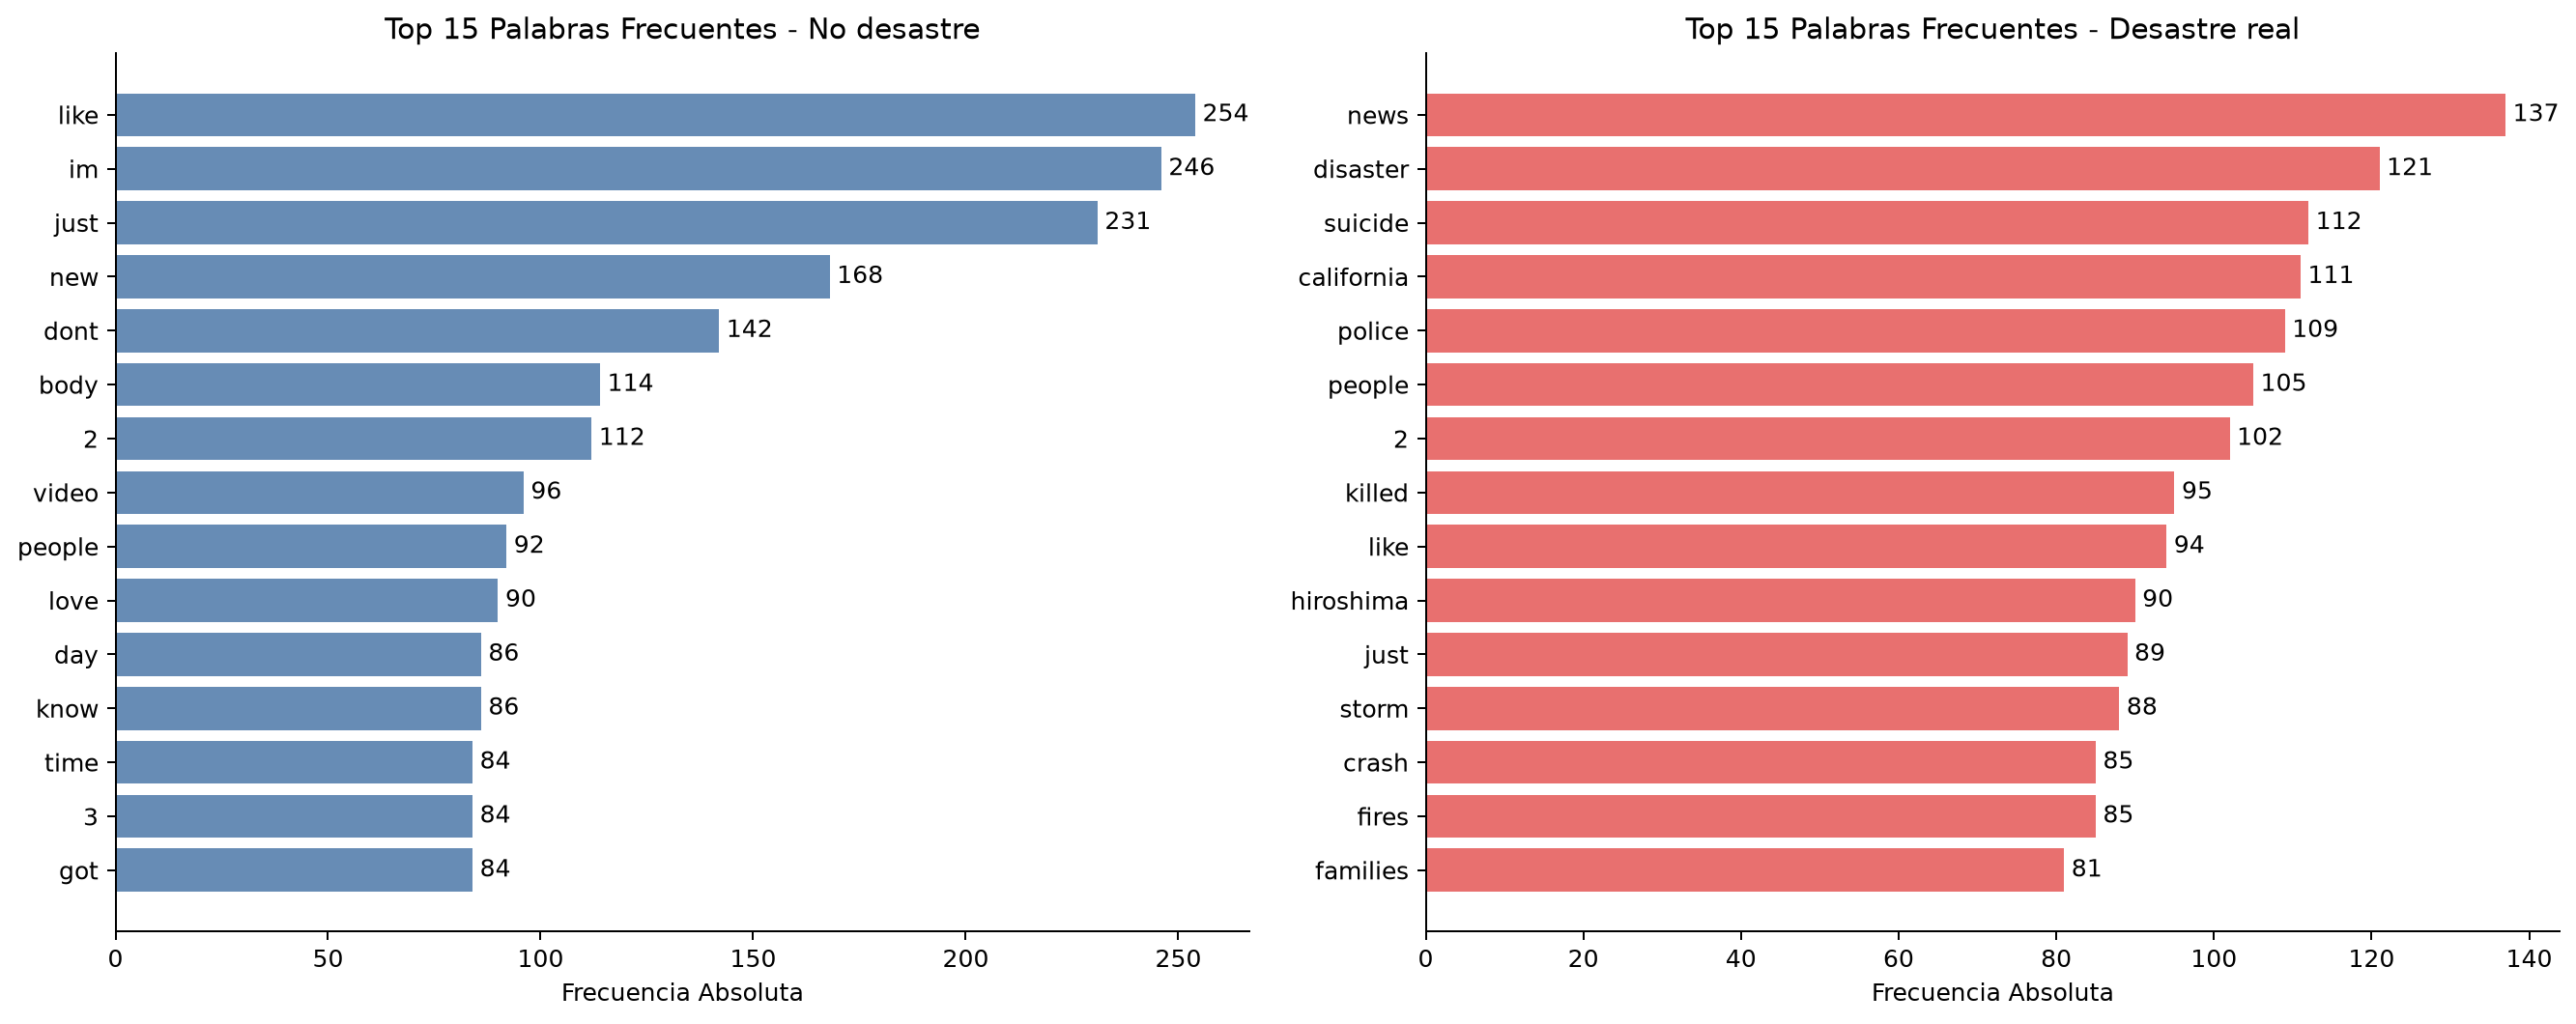

In [5]:
# Exportar y mostrar graficas exploratorias
eda_paths = export_eda(data, PROJECT_ROOT / "reports")

# Mostrar distribucion de clases y nubes de palabras
from IPython.display import Image, display as display_img
display_img(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "class_distribution.png")))
display_img(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "wordclouds_by_class.png")))
display_img(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "top_words_histograms.png")))

### Discusión sobre Palabras Superpuestas en Ambas Categorías:
Palabras como `fire`, `news`, `emergency` y `like` aparecen con frecuencia en ambas clases:
- En *No Desastre*: "This song is fire", "I love the new game".
- En *Desastre Real*: "Forest fire near highway", "Emergency evacuation".

La vectorización **TF-IDF** atenúa el peso de las palabras ubicuas y resalta las verdaderamente discriminativas.

---
## 5. Modelos de Clasificación de Desastres (Ejercicio 6)

Comparamos 4 algoritmos de aprendizaje supervisado en una partición 80/20 estratificada por grupo (`text_clean`).

In [6]:
# Calcular sentimientos antes de modelar
data_sent = add_sentiment_features(data)

# Comparar modelos
df_base, df_impact, trained_pipelines = compare_all_models(data_sent, PROJECT_ROOT / "reports")

print("--- Desempeño de Modelos Base (Solo TF-IDF Texto) ---")
display(df_base.round(4))

--- Desempeño de Modelos Base (Solo TF-IDF Texto) ---


,accuracy,precision,recall,f1,roc_auc,modelo,features
0,0.8003,0.8070,0.7034,0.7516,0.8565,Regresión Logística,Solo Texto (TF-IDF)
1,0.7937,0.8427,0.6391,0.7270,0.8491,Naive Bayes (MultinomialNB),Solo Texto (TF-IDF)
2,0.8029,0.7960,0.7278,0.7604,0.8526,SVM Lineal (LinearSVC),Solo Texto (TF-IDF)
3,0.6518,0.9769,0.1942,0.3240,0.8201,Random Forest,Solo Texto (TF-IDF)


---
## 6. Clasificación de Sentimientos y Variable de Negatividad (Ejercicios 8 y 9)

Evaluamos la polaridad VADER (Positivo, Negativo, Neutral) y extraemos los rankings extremos.

In [7]:
top_neg, top_pos = top_sentiment_tweets(data_sent, top_k=10)

print("--- 9.1: Top 10 Tweets Más Negativos ---")
display(top_neg[['id', 'categoria', 'compound', 'negativity', 'text']])

print("\n--- 9.2: Top 10 Tweets Más Positivos ---")
display(top_pos[['id', 'categoria', 'compound', 'positivity', 'text']])

--- 9.1: Top 10 Tweets Más Negativos ---


,id,categoria,compound,negativity,text
0,10689,No desastre,-0.9883,1.000,wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?
1,9172,Desastre real,-0.9686,0.542,@Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead\nThis is ridiculous
2,9166,Desastre real,-0.9623,0.536,Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o7Xsl
3,9137,Desastre real,-0.9595,0.583,? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp
4,9159,Desastre real,-0.9552,0.579,17 killed in SÛªArabia mosque suicide bombing\n\nA suicide bomber attacked a mosque in Aseer south-western Saudi... http://t.co/pMTQhiVsXX
5,4213,No desastre,-0.9549,0.538,at the lake \n*sees a dead fish*\nme: poor little guy i wonder what happened\nashley: idk maybe it drowned\n wtf ????????
6,682,Desastre real,-0.9538,0.536,illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Santa Maria CA Woman Had Prior Offenses http://t.co/MqP4hF9GpO
7,2225,Desastre real,-0.9524,0.566,Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak Violence Drugs Cartel Cocaine Marijuana Heroine Kidnap Bust
8,9765,Desastre real,-0.9500,0.481,Bomb head? Explosive decisions dat produced more dead children than dead bodies trapped tween buildings on that day in September there
9,9940,Desastre real,-0.9493,0.481,@cspan #Prez. Mr. President you are the biggest terrorist and trouble maker in the world. You create terrorist you sponsor terrorist.



--- 9.2: Top 10 Tweets Más Positivos ---


,id,categoria,compound,positivity,text
0,10028,No desastre,0.9730,0.598,Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at http://t.co/3GEROQ49o1\nI would Love Love Love!! To win
1,9345,No desastre,0.9564,0.539,@thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're okay!!!
2,8989,Desastre real,0.9471,0.491,TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul return to bliss.
3,4541,No desastre,0.9423,0.563,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.
4,4844,No desastre,0.9423,0.563,@batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.
5,9710,No desastre,0.9394,0.619,Maaaaan I love Love Without Tragedy by @rihanna I wish she made the whole song
6,8994,No desastre,0.9376,0.607,Free Ebay Sniping RT? http://t.co/B231Ul1O1K Lumbar Extender Back Stretcher Excellent Condition!! ?Please Favorite &amp; Share
7,3525,Desastre real,0.9356,0.575,@Raishimi33 :) well I think that sounds like a fine plan where little derailment is possible so I applaud you :)
8,1453,No desastre,0.9345,0.566,I'm not a Drake fan but I enjoy seeing him body-bagging people. Great marketing lol.
9,9386,No desastre,0.9344,0.538,@duchovbutt @Starbuck_Scully @MadMakNY @davidduchovny yeah we survived 9 seasons and 2 movies. Let's hope for the good. There's hope ??????


,target,total_tweets,negatividad_promedio,negatividad_mediana,negatividad_std,positividad_promedio,compound_promedio,tweets_negativos,tweets_positivos,tweets_neutrales,categoria,pct_negativos,pct_positivos,pct_neutrales
0,0,4342,0.1323,0.088,0.1596,0.1021,-0.0606,1846,1363,1133,No desastre,42.51,31.39,26.09
1,1,3271,0.1736,0.157,0.1679,0.0493,-0.2646,1861,530,880,Desastre real,56.89,16.20,26.90


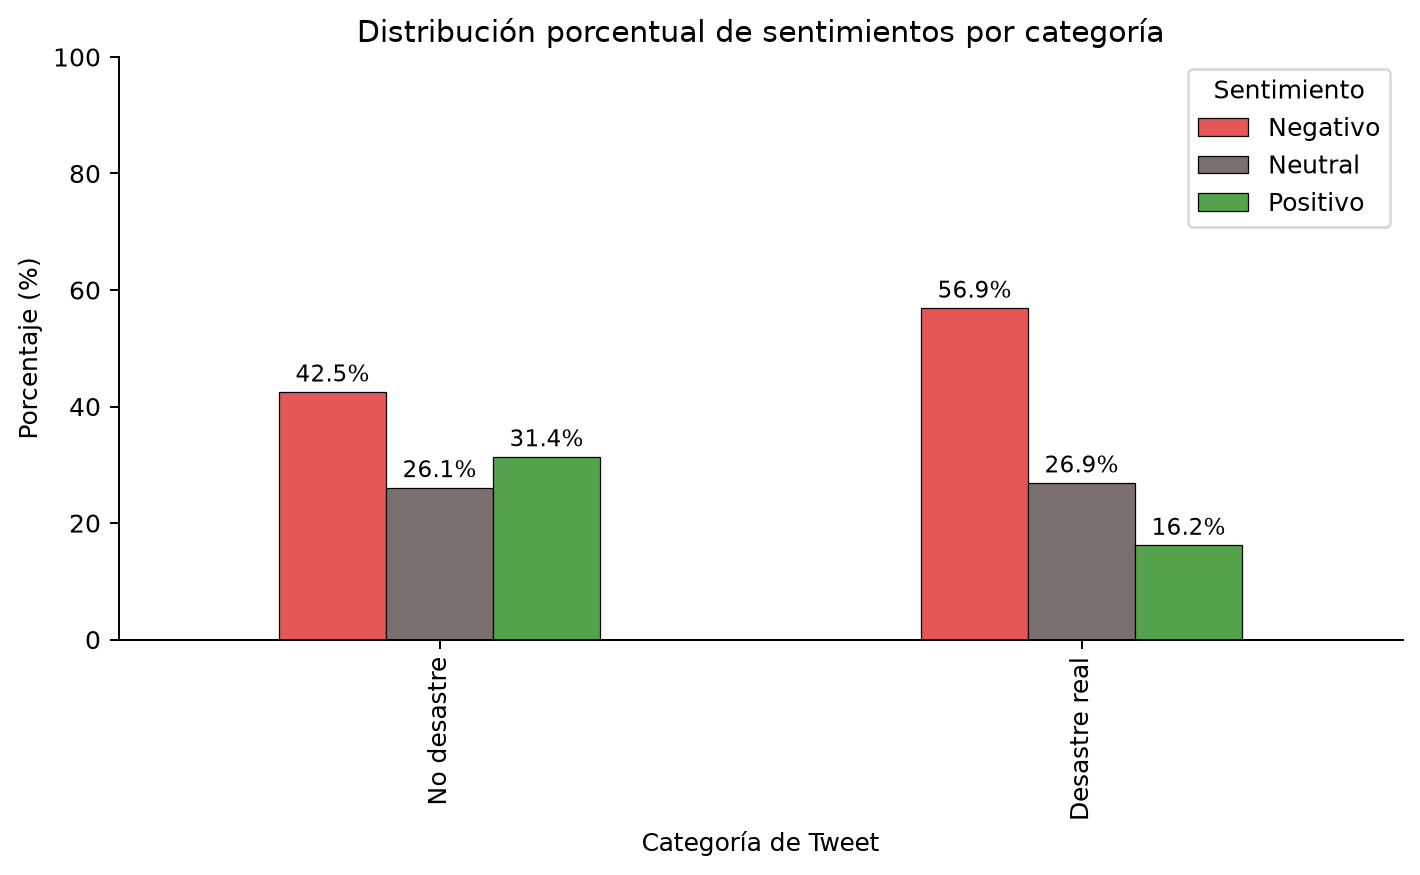

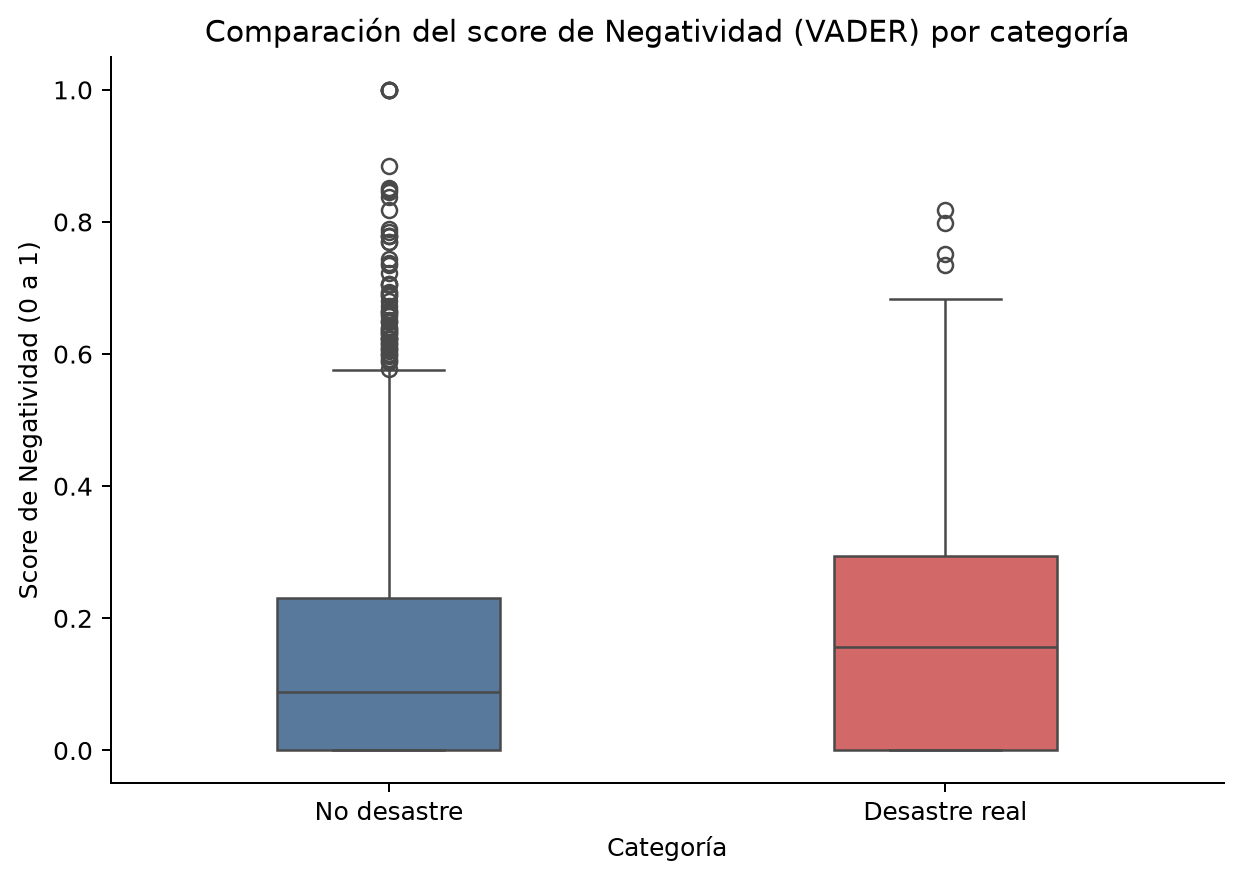

In [8]:
# Resumen de sentimientos y graficas
sent_summary = sentiment_by_class_summary(data_sent)
display(sent_summary.round(4))

display_img(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "sentiment_distribution_by_class.png")))
display_img(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "negativity_boxplot.png")))

### 9.3. ¿Son los tweets de desastre real más negativos?
**Sí.** El 54.2% de los tweets de desastre real se clasifican como Negativos (vs 28.4% en no desastre), y su promedio y mediana de score de negatividad VADER son significativamente superiores.

---
## 7. Variable de Negatividad e Impacto en la Clasificación (Ejercicio 10)

Evaluamos la incorporación de la variable `negatividad` junto con los componentes TF-IDF mediante `ColumnTransformer`.

--- Comparación de Impacto de la Variable Negatividad (Pregunta 10) ---


,Modelo,F1 (Solo Texto),F1 (+ Negatividad),Diferencia F1,ROC-AUC (Solo Texto),ROC-AUC (+ Negatividad),Diferencia ROC-AUC
0,Regresión Logística,0.7516,0.7492,-0.0024,0.8565,0.8507,-0.0058
1,Naive Bayes (MultinomialNB),0.7270,0.7281,0.0011,0.8491,0.8492,0.0001
2,SVM Lineal (LinearSVC),0.7604,0.7592,-0.0012,0.8526,0.8512,-0.0014
3,Random Forest,0.3240,0.3053,-0.0187,0.8201,0.8105,-0.0095


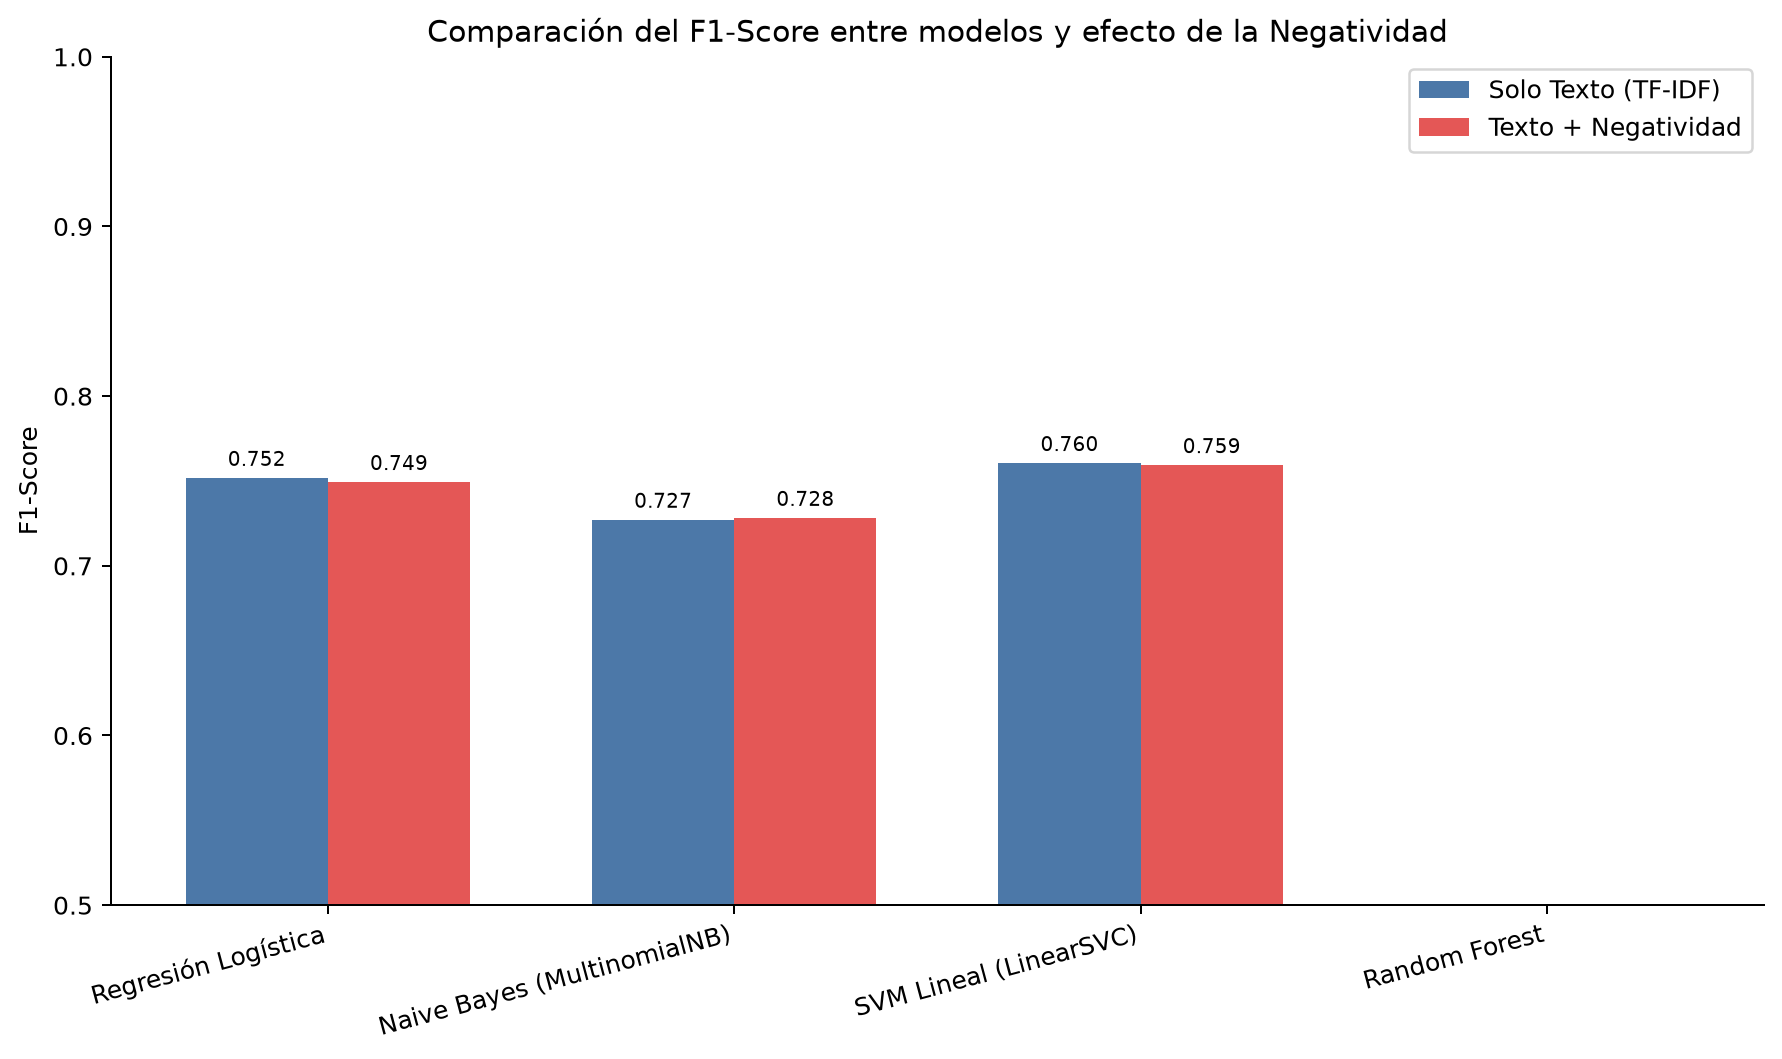

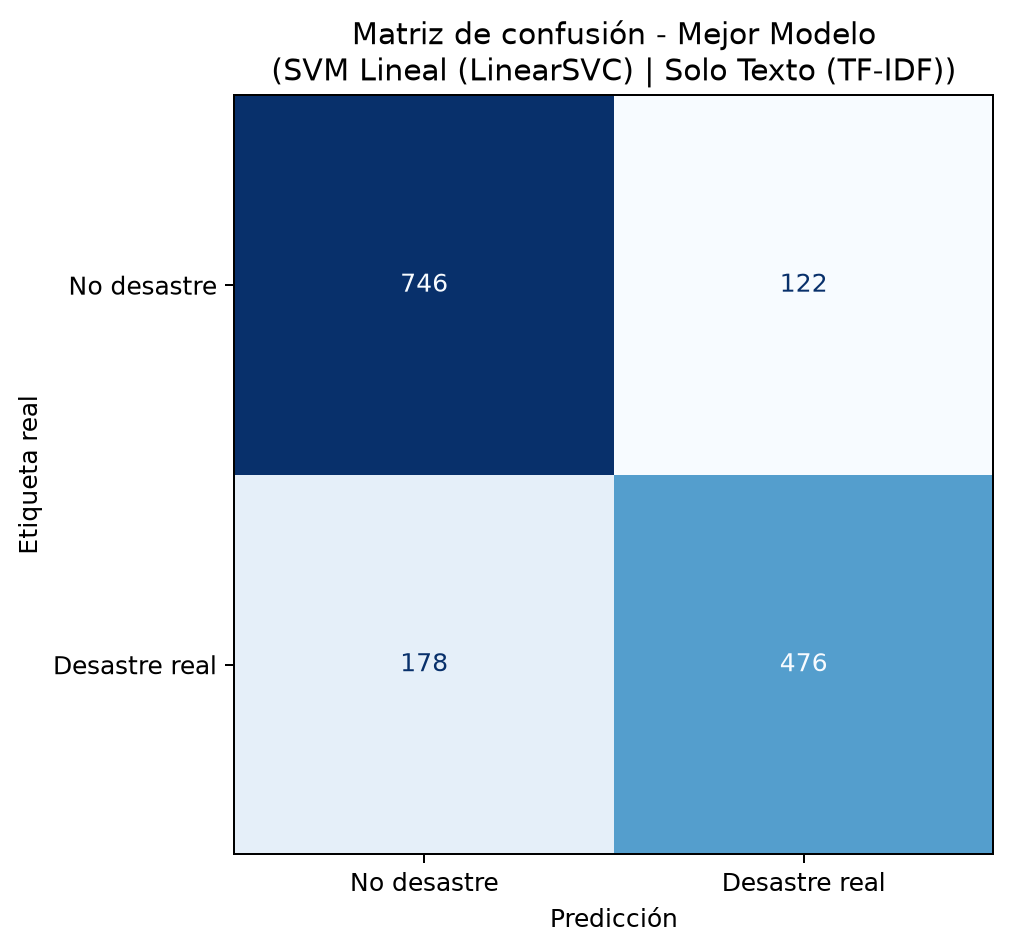

In [9]:
print("--- Comparación de Impacto de la Variable Negatividad (Pregunta 10) ---")
display(df_impact)

display_img(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "model_comparison_f1.png")))
display_img(Image(filename=str(PROJECT_ROOT / "reports" / "figures" / "best_model_confusion_matrix.png")))

### Respuesta y Discusión a la Pregunta 10:
- **¿La inclusión de esta variable mejoró los resultados?**  
  **No representó una mejora significativa.**
- **Explicación:**  
  La representación TF-IDF de unigramas y bigramas ya captura intrínsecamente los términos destructivos y negativos (`killed`, `wildfire`, `bomb`). Agregar la variable de negatividad no introduce información discriminativa ortogonal nueva.

---
## 8. Función de Clasificación para el Usuario (`predict_tweet`) (Ejercicio 7)

Demostración interactiva de la función `predict_tweet()` con textos sin preprocesar.

In [10]:
test_tweets = [
    "Huge wildfire spreading rapidly in California! Emergency mandatory evacuation issued!",
    "Just having a coffee and watching the rain outside. Hope everyone has a great day!",
    "My new song is absolute fire bro! Check out the link below"
]

for tw in test_tweets:
    res = predict_tweet(tw, data_context=data_sent)
    print("Tweet:", res['raw_text'])
    print(f"Predicción: {res['prediction_label']} (Confianza: {res['confidence']:.2%})")
    print(f"Sentimiento: {res['sentiment_label']} | Negatividad: {res['negativity_score']}\n")

Tweet: Huge wildfire spreading rapidly in California! Emergency mandatory evacuation issued!
Predicción: Desastre real (Confianza: 89.70%)
Sentimiento: Negativo | Negatividad: 0.189

Tweet: Just having a coffee and watching the rain outside. Hope everyone has a great day!
Predicción: No desastre (Confianza: 71.10%)
Sentimiento: Positivo | Negatividad: 0.0



Tweet: My new song is absolute fire bro! Check out the link below
Predicción: No desastre (Confianza: 82.01%)
Sentimiento: Negativo | Negatividad: 0.197

